# E-commerce Customer Behavior Analytics

This project analyzes customer purchase behavior to identify high-value customers, sales trends, and business insights.

### Import Libraries

We import required libraries for data analysis and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

We load the dataset using pandas. This dataset contains transaction-level data such as invoice number, product, quantity, price, and customer ID.

In [2]:
df = pd.read_excel('/content/Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Data Overview

We check dataset shape, column types, and missing values to understand the structure of the data.

In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### Initial Observations

- Dataset contains transactional records
- Some columns have missing values (especially CustomerID)
- Quantity and UnitPrice will be important for revenue calculation

## Handling Missing Values

We check for missing values to identify columns that need cleaning.
CustomerID is important for customer analysis, so missing values must be handled.

In [6]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


### Handling Missing CustomerID

A large number of records have missing CustomerID.

Since the goal is customer behavior analysis, these records cannot be used for tracking individual customers.

Therefore, rows with missing CustomerID are removed to ensure accurate customer segmentation.

In [7]:
df = df.dropna(subset=['CustomerID'])

### Handling Missing Product Description

Some rows have missing product descriptions.
We replace them with 'Unknown' to maintain data consistency.

In [8]:
df['Description'] = df['Description'].fillna('Unknown')

### Removing Invalid Quantity

Negative quantities represent product returns.
We remove them to analyze only actual purchases.

In [9]:
df = df[df['Quantity'] > 0]

### Removing Invalid Prices

UnitPrice should be positive.
Rows with zero or negative price are removed.

In [10]:
df = df[df['UnitPrice'] > 0]

### Creating Revenue Column

Revenue is calculated as Quantity × UnitPrice.
This will help in sales and customer value analysis.

In [11]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

### Data Type Correction

CustomerID is converted to integer for better readability and consistency.

In [12]:
df['CustomerID'] = df['CustomerID'].astype(int)

### Final Cleaned Data Overview

We verify that the dataset is clean and ready for analysis.

In [13]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  int64         
 7   Country      397884 non-null  object        
 8   Revenue      397884 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 30.4+ MB


(397884, 9)

## Total Revenue

We calculate total revenue generated to understand overall business performance.

In [14]:
total_revenue = df['Revenue'].sum()
total_revenue

np.float64(8911407.904)

## Revenue by Country

We analyze revenue contribution by country to identify top-performing markets.

In [15]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
country_revenue.head(10)

,Revenue
Country,
United Kingdom,7308391.554
Netherlands,285446.340
EIRE,265545.900
Germany,228867.140
France,209024.050
Australia,138521.310
Spain,61577.110
Switzerland,56443.950
Belgium,41196.340


## Top 10 Countries by Revenue

Visualization helps identify which countries generate the most revenue.

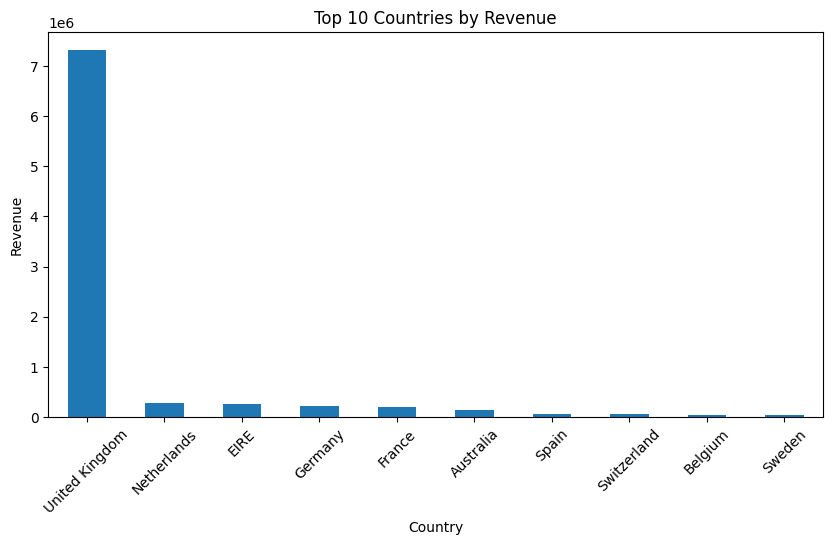

In [16]:
plt.figure(figsize=(10,5))
country_revenue.head(10).plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

## Monthly Trend Analysis

We extract month from InvoiceDate to analyze sales trends over time.

In [17]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

## Monthly Revenue

We calculate total revenue per month to identify seasonal trends.

In [18]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()
monthly_revenue

,Revenue
Month,
2010-12,572713.890
2011-01,569445.040
2011-02,447137.350
2011-03,595500.760
2011-04,469200.361
2011-05,678594.560
2011-06,661213.690
2011-07,600091.011
2011-08,645343.900


## Monthly Revenue Trend

This helps identify peak sales periods and seasonality.

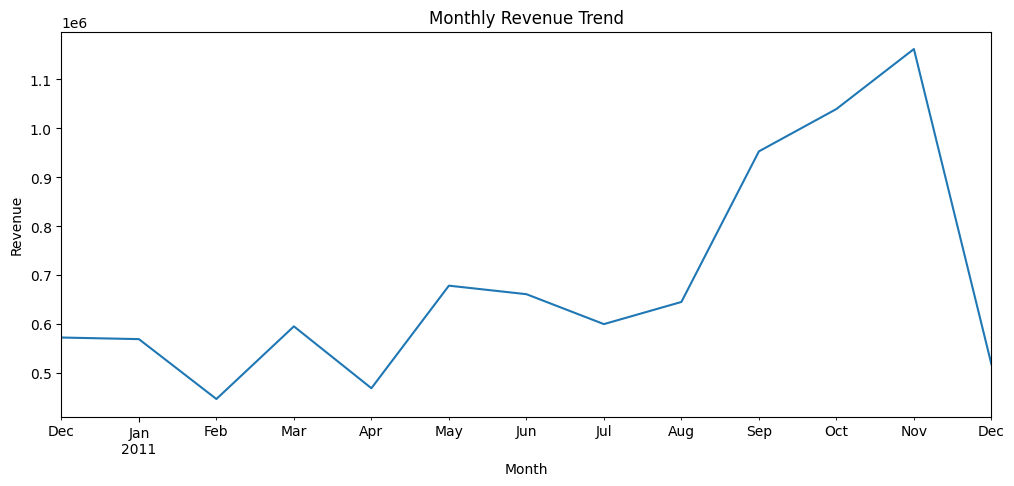

In [19]:
monthly_revenue.plot(figsize=(12,5))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

## Top-Selling Products

We identify products generating highest revenue.

In [20]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False)
top_products.head(10)

,Revenue
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142592.95
WHITE HANGING HEART T-LIGHT HOLDER,100448.15
JUMBO BAG RED RETROSPOT,85220.78
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68844.33
ASSORTED COLOUR BIRD ORNAMENT,56580.34
Manual,53779.93


## Top 10 Products by Revenue

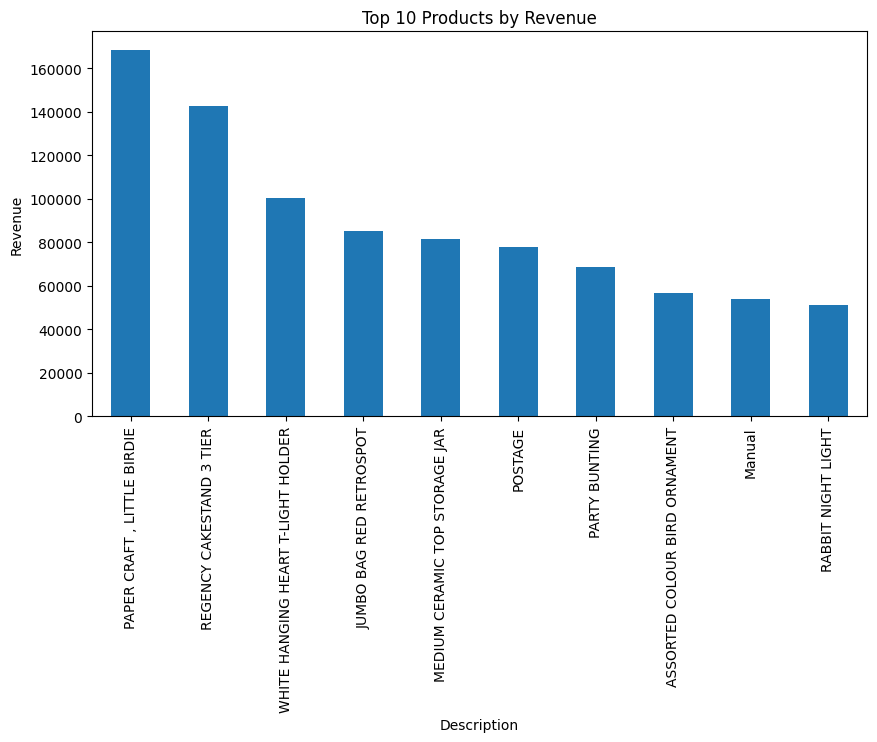

In [21]:
top_products.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Products by Revenue")
plt.ylabel("Revenue")
plt.show()

## Key Insights

- United Kingdom contributes the highest revenue among all countries
- Sales peak during November indicating strong seasonal demand
- A small number of products contribute significantly to total revenue
- Revenue shows a rising trend from September to November

## Reference Date for Recency

We define a reference date (latest date in dataset + 1 day)
to calculate how recently a customer made a purchase.

In [22]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

## Creating RFM Table

We group data by CustomerID to calculate:
- Recency: Days since last purchase
- Frequency: Number of transactions
- Monetary: Total revenue

In [23]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


## RFM Scoring

We assign scores from 1 to 5 for each metric:
- Recency: lower is better
- Frequency: higher is better
- Monetary: higher is better

In [24]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

## RFM Score

We combine R, F, M scores to create a single RFM score for segmentation.

In [25]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346,326,1,77183.60,1,1,5,115
12347,2,7,4310.00,5,5,5,555
12348,75,4,1797.24,2,4,4,244
12349,19,1,1757.55,4,1,4,414
12350,310,1,334.40,1,1,2,112


## Customer Segmentation

We classify customers into segments based on RFM scores.

In [26]:
def segment_customer(row):
    if row['RFM_Score'] == '555':
        return 'VIP'
    elif row['F_score'] >= 4:
        return 'Loyal'
    elif row['R_score'] <= 2:
        return 'At Risk'
    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
CustomerID,,,,,,,,
12346,326,1,77183.60,1,1,5,115,At Risk
12347,2,7,4310.00,5,5,5,555,VIP
12348,75,4,1797.24,2,4,4,244,Loyal
12349,19,1,1757.55,4,1,4,414,Regular
12350,310,1,334.40,1,1,2,112,At Risk


## Customer Segments Distribution

We analyze how customers are distributed across segments.

In [27]:
rfm['Segment'].value_counts()

,count
Segment,
At Risk,1433
Loyal,1387
Regular,1170
VIP,348


## Customer Segmentation Visualization

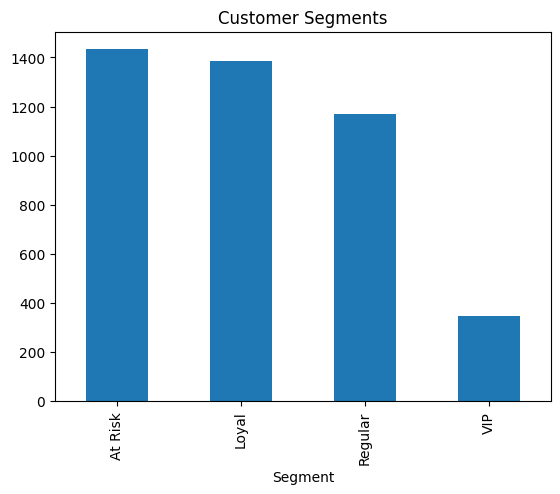

In [28]:
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments")
plt.show()

## Customer Insights

- A large number of customers fall under the "At Risk" segment, indicating potential churn
- VIP customers are fewer but contribute significantly to revenue
- Loyal customers form a stable base for repeat purchases
- Business should focus on retention strategies for at-risk customers

## Export Clean Dataset

We export the cleaned dataset for dashboard creation in Power BI.

In [29]:
df.to_csv('cleaned_ecommerce_data.csv', index=False)
rfm.to_csv('rfm_customer_segments.csv')